# Ziak est-il un autre rappeur ? Une enquête stylométrique

Ziak est apparu dans le rap français en 2020, cagoulé, sans identité civile publique.
Cette discrétion a nourri une hypothèse récurrente parmi les auditeurs : le nom
masquerait un artiste déjà établi, qui aurait recommencé une carrière sous un
pseudonyme. C'est une hypothèse *testable*. Si Ziak est le second nom d'un rappeur
présent dans le corpus, ses textes devraient porter la même signature statistique que
ceux de cet artiste.

Ce notebook conduit ce test sur le corpus **LRFAF** (37 307 chansons de rap français),
et rend compte d'un résultat qui n'était pas acquis d'avance : **aucun des 392 autres artistes
éligibles du corpus ne correspond**, et l'on peut chiffrer la confiance à accorder à
cette conclusion.

L'enjeu principal n'est pas l'algorithme mais le **protocole**. Une démarche
intuitive produit ici un classement d'apparence convaincante et pourtant faux : on
montre en section 2 qu'il se trompe trois fois sur quatre. La difficulté d'une question
d'attribution n'est pas de calculer des distances, c'est de savoir ce qu'elles valent.

## Plan

1. Le corpus et le cas Ziak
2. Pourquoi la démarche intuitive désigne le mauvais artiste
3. Un protocole validé sur des cas dont on connaît la réponse
4. Application à Ziak : contrôle positif, candidats, verdict
5. Robustesse : la conclusion tient-elle ?
6. Portrait stylométrique de Ziak
7. Limites de l'étude
8. Conclusion et note éthique

## Reproduire l'analyse

Les calculs lourds sont dans des scripts versionnés à la racine, à exécuter dans
l'ordre. Ce notebook lit leurs sorties (`result/`, `images/`) et les commente.

```bash
python3 stylo_features.py            # cache des compteurs (~1 min)
python3 02_diagnostic_biais_taille.py
python3 03_validation_protocole.py
python3 04_attribution_ziak.py
python3 05_robustesse.py
python3 06_profil_stylistique.py
python3 07_figures.py
```

## 1. Le corpus et le cas Ziak

### 1.1 Configuration

Conventions du projet : scripts et notebooks à la racine, figures dans `images/`,
tables dans `result/`.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import Image, display

IMAGES_DIR = Path("images")
RESULT_DIR = Path("result")
IMAGES_DIR.mkdir(exist_ok=True)
RESULT_DIR.mkdir(exist_ok=True)

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 160)

# Le cache est construit par stylo_features.py : comptes par chanson, ce qui
# permet de recomposer des documents de taille arbitraire sans relire le CSV.
from stylo_features import build_cache

cache = build_cache()
meta = cache["meta"]
print(f"{len(meta):,} chansons retenues, {meta['artist'].nunique():,} artistes")

32,923 chansons retenues, 596 artistes


### 1.2 Le corpus de Ziak

La stylométrie a besoin de matière. On vérifie d'abord que Ziak en fournit assez :
les méthodes employées ici demandent quelques milliers de mots pour être stables.

In [2]:
TARGET = "Ziak"
ziak = meta[meta["artist"] == TARGET]
totals = meta.groupby("artist")["n_tokens"].sum()

print(f"{TARGET} : {len(ziak)} titres, {int(totals[TARGET]):,} mots")
print(f"Période      : {ziak['year'].min()}-{ziak['year'].max()}")
print(f"Rang de taille dans le corpus : {int((totals > totals[TARGET]).sum()) + 1} "
      f"/ {len(totals)}")
print()
print(ziak.groupby("year").agg(n_titres=("title", "size"),
                               n_mots=("n_tokens", "sum")).to_string())

Ziak : 43 titres, 23,886 mots
Période      : 2020-2024
Rang de taille dans le corpus : 275 / 596

      n_titres  n_mots
year                  
2020         8    3775
2021        15    9329
2022         2    1104
2023        17    9170
2024         1     508


Environ 24 000 mots répartis sur 43 titres : un corpus modeste mais très au-dessus
du seuil usuel (quelques milliers de mots) pour ce type d'analyse. La section 4.1
vérifiera empiriquement que cette matière suffit.

Un point de vocabulaire, car il commande tout le reste. On cherche ici une
**vérification d'auteur** en ensemble *ouvert* : la bonne réponse peut ne pas figurer
dans le corpus. C'est une tâche plus difficile que l'attribution en ensemble fermé,
où l'on sait que l'auteur est l'un des candidats. Une méthode d'ensemble fermé
désigne *toujours* quelqu'un — d'où la nécessité d'un protocole capable de répondre
« personne ».

## 2. Pourquoi la démarche intuitive désigne le mauvais artiste

### 2.1 Ce que mesure vraiment un classement naïf

La démarche spontanée : concaténer toutes les chansons de chaque artiste, vectoriser,
classer par distance à Ziak. Elle produit un palmarès plausible. Le problème apparaît
quand on le confronte à une variable qui n'a rien à voir avec le style — la simple
quantité de texte disponible sur chaque artiste.

In [3]:
comp = pd.read_csv(RESULT_DIR / "02_1_classement_naif_vs_controle.csv")
synth = pd.read_csv(RESULT_DIR / "02_4_synthese_diagnostic.csv", index_col=0).iloc[:, 0]

print(f"Corrélation de Spearman entre la distance à Ziak et la taille du corpus")
print(f"du candidat : rho = {float(synth['spearman_distance_vs_taille']):.3f}")
print(f"-> {float(synth['part_variance_expliquee_par_taille']):.0%} de la variance du "
      f"classement tient à la seule quantité de texte.\n")

print(f"Taille médiane des 20 « plus proches » : "
      f"{comp.nsmallest(20, 'distance_naive')['n_tokens_corpus'].median():,.0f} mots")
print(f"Taille médiane de l'ensemble du pool   : "
      f"{comp['n_tokens_corpus'].median():,.0f} mots")

comp.nsmallest(8, "distance_naive")[
    ["rang_naif", "artiste", "n_tokens_corpus", "rang_controle"]
]

Corrélation de Spearman entre la distance à Ziak et la taille du corpus
du candidat : rho = -0.468
-> 22% de la variance du classement tient à la seule quantité de texte.

Taille médiane des 20 « plus proches » : 76,296 mots
Taille médiane de l'ensemble du pool   : 34,262 mots


,rang_naif,artiste,n_tokens_corpus,rang_controle
0,1,ISK,53505,2
1,2,Niro,140156,42
2,3,Sadek,117259,124
3,4,Ninho,94373,14
4,5,SCH,72639,21
5,6,Zkr,81076,5
6,7,Lacrim,121702,48
7,8,Nahir,47664,20


Le mécanisme est arithmétique, pas musical : plus un artiste a écrit, plus son
vecteur couvre de n-grammes, et plus il ressemble à n'importe quel texte. Les vingt
« plus proches » de Ziak ont un corpus deux fois plus gros que la médiane. Le
classement mesure la productivité, pas le style.

Une fois la taille neutralisée, il ne reste presque rien du palmarès : Mister You
passe du 9ᵉ au 138ᵉ rang, Sadek du 3ᵉ au 124ᵉ.

### 2.2 Chiffrer l'erreur

L'argument décisif n'est pas qu'un classement change, c'est qu'on peut mesurer
lequel a raison. On soumet les trois variantes à des cas dont la réponse est connue :
on prélève chez un artiste un échantillon de la taille du corpus de Ziak, on le traite
comme un texte anonyme, et on regarde si la méthode le rattache au reste de son œuvre.

In [4]:
perf = pd.read_csv(RESULT_DIR / "02_3_puissance_par_variante.csv")
perf.style.format({"recall_at_1": "{:.1%}", "recall_at_5": "{:.1%}",
                   "recall_at_20": "{:.1%}", "rang_median": "{:.0f}",
                   "rang_moyen": "{:.1f}"}).hide(axis="index")

variante,recall_at_1,recall_at_5,recall_at_20,rang_median,rang_moyen
A. naïve (corpus complets),25.0%,45.5%,67.4%,7,24.9
B. taille contrôlée,73.5%,87.4%,95.1%,1,4.4
C. taille contrôlée + Cosine Delta,91.5%,97.7%,99.8%,1,1.3


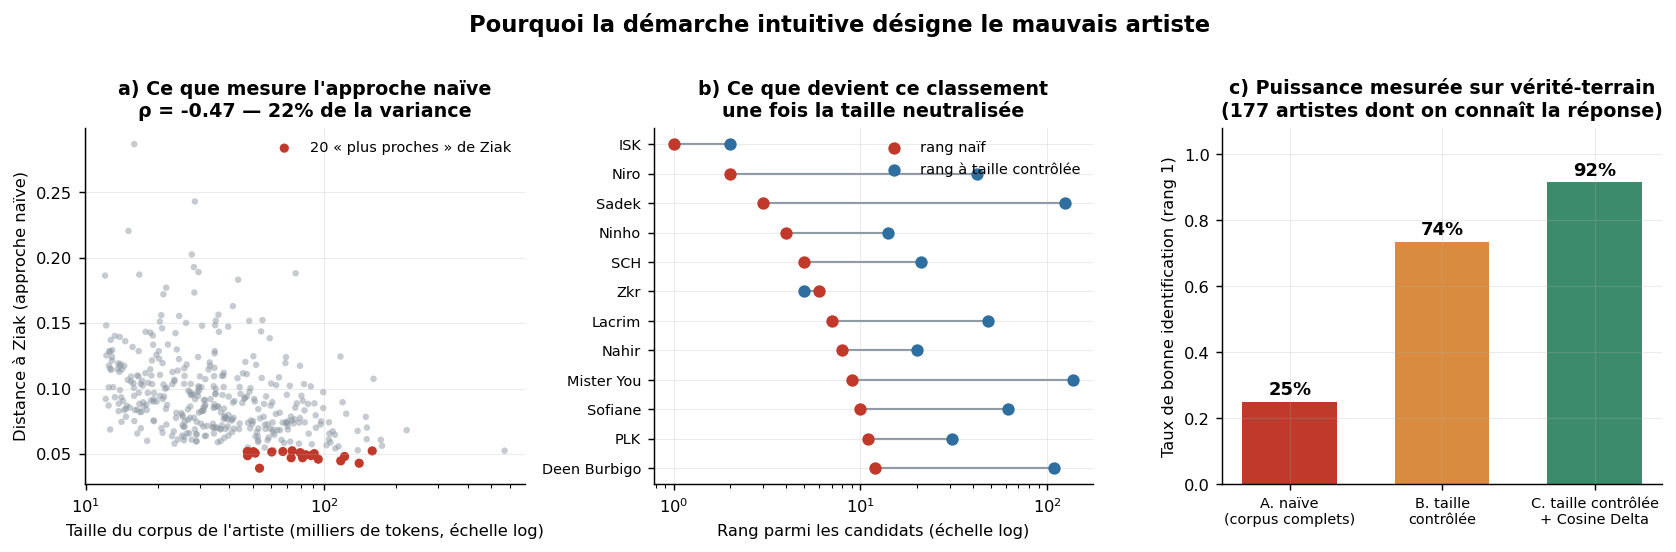

In [5]:
display(Image(filename=str(IMAGES_DIR / "02_1_biais_de_taille.png")))

**L'approche naïve identifie le bon auteur dans 25 % des cas seulement** — elle se
trompe trois fois sur quatre, alors même qu'elle produit un classement d'allure
sérieuse. Ramener tous les documents à la même taille fait passer ce taux à 74 %, et
standardiser les traits (Cosine Delta) à 92 %. (Ce dernier chiffre et les 90 % de la
section 3 mesurent la même chose sur deux expériences distinctes — 6 et 10
rééchantillonnages — d'où le léger écart.)

C'est la leçon centrale de cette section : sans étalonnage, un classement de distances
ne permet aucune conclusion, quelle que soit sa netteté apparente.

## 3. Un protocole validé sur des cas dont on connaît la réponse

### 3.1 Le dispositif

Le protocole retenu (script `03_validation_protocole.py`) repose sur trois choix :

- **Traits** : 4-grammes de caractères et 500 mots les plus fréquents. Ces
  descripteurs captent des habitudes d'écriture largement inconscientes — élisions,
  enchaînements grammaticaux — plutôt que les thèmes abordés.
- **Distances** : Cosine Delta (Smith & Aldridge, 2011) et Delta de Burrows (1992),
  toutes deux calculées sur des traits standardisés.
- **Taille contrôlée** : 12 000 mots par candidat, échantillonnés parmi ses titres.

Chaque artiste de contrôle est traité *exactement* comme Ziak : on lui prélève un
texte-requête de la taille du corpus de Ziak, et un « jumeau » de 12 000 mots issu de
titres disjoints, placé dans le pool. Deux conditions sont évaluées :

- **H1** — le jumeau est dans le pool : mesure la puissance de la méthode ;
- **H0** — le jumeau en est retiré : reproduit la situation d'un auteur absent du
  corpus, c'est-à-dire l'hypothèse à laquelle Ziak devra être confronté.

In [6]:
puissance = pd.read_csv(RESULT_DIR / "03_2_puissance_methode.csv")
puissance.style.format({c: "{:.1%}" for c in
                        ["recall_at_1", "recall_at_5", "recall_at_10", "recall_at_20"]}
                       | {"rang_median": "{:.0f}", "sep_top1_moy": "{:.2f}"}
                       ).hide(axis="index")

features,metric,recall_at_1,recall_at_5,recall_at_10,recall_at_20,rang_median,sep_top1_moy,n_essais
char,cosine_delta,90.0%,98.5%,99.3%,99.7%,1,-4.46,1770
mfw,cosine_delta,85.0%,96.6%,99.0%,99.4%,1,-4.64,1770
mfw,burrows_delta,79.1%,92.0%,94.9%,97.6%,1,-3.10,1770
char,burrows_delta,65.3%,85.6%,91.1%,95.2%,1,-2.79,1770


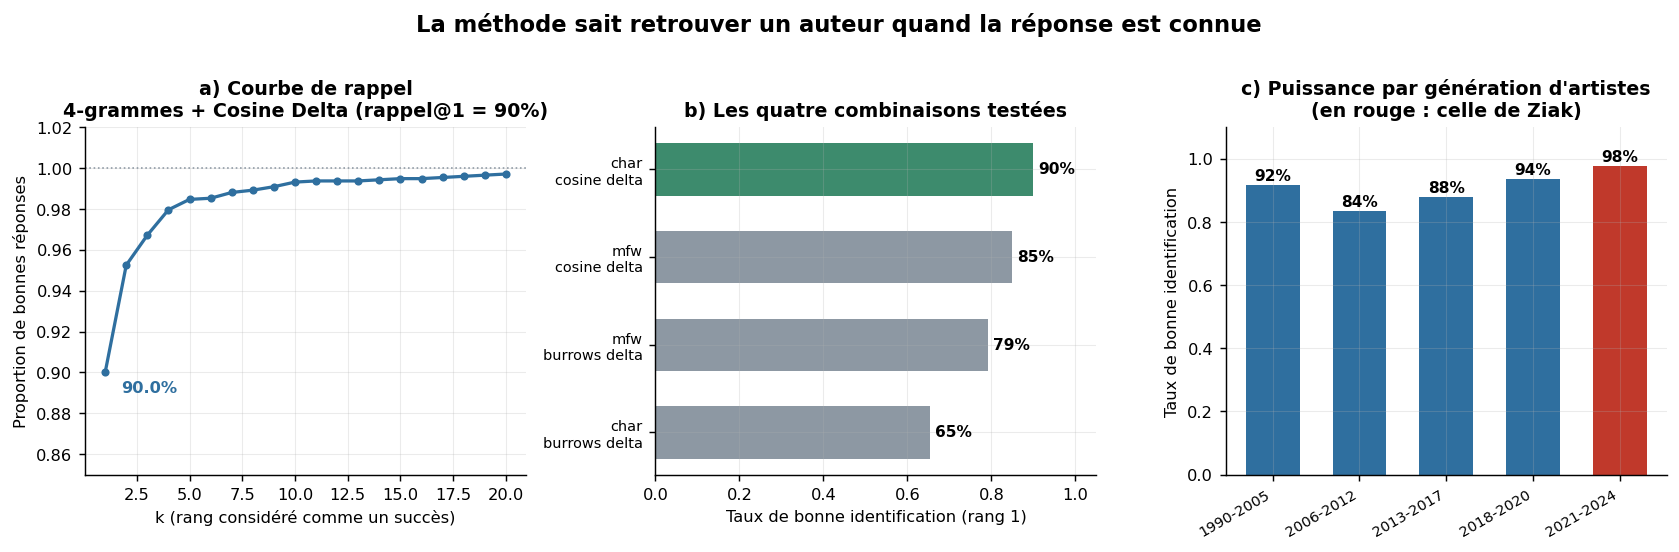

In [7]:
display(Image(filename=str(IMAGES_DIR / "03_1_validation.png")))

La meilleure combinaison — 4-grammes de caractères et Cosine Delta — **retrouve le
bon auteur au premier rang dans 90 % des cas, et dans le top 5 dans 98,5 %**, sur
1 770 essais couvrant 177 artistes. C'est cette puissance élevée qui rendra un
résultat négatif informatif : si un alias existait dans le corpus, la méthode aurait
neuf chances sur dix de le désigner en tête.

### 3.2 Les seuils de décision

La distance brute au meilleur candidat ne se lit pas seule. On lui substitue un
**score de séparation** : de combien d'écarts-types le meilleur candidat se détache-t-il
des autres ? Cette grandeur est comparable d'une requête à l'autre, et sa distribution
diffère nettement selon que l'auteur est présent ou absent.

In [8]:
seuils = pd.read_csv(RESULT_DIR / "03_3_seuils_decision.csv")
seuils[["features", "metric", "sep_H1_correct_moy", "sep_H0_moy", "sep_H0_sd",
        "ecart_H1_H0"]].style.format(
    {c: "{:.2f}" for c in ["sep_H1_correct_moy", "sep_H0_moy", "sep_H0_sd",
                           "ecart_H1_H0"]}).hide(axis="index")

features,metric,sep_H1_correct_moy,sep_H0_moy,sep_H0_sd,ecart_H1_H0
char,burrows_delta,-3.01,-2.33,0.25,0.46
char,cosine_delta,-4.59,-3.05,0.54,1.41
mfw,burrows_delta,-3.27,-2.40,0.26,0.70
mfw,cosine_delta,-4.83,-3.26,0.62,1.39


Avec les 4-grammes et Cosine Delta, un auteur réellement présent produit une
séparation moyenne de **−4,59** ; un auteur absent, de **−3,05**. Ces deux
distributions se chevauchent partiellement, mais leur écart fournit un critère de
décision explicite, que l'on peut appliquer à Ziak.

## 4. Application à Ziak

### 4.1 Contrôle positif : le style de Ziak est-il seulement détectable ?

Avant d'interpréter un échec d'identification, il faut écarter l'explication triviale :
un corpus trop petit ou trop hétérogène pour porter une signature. On coupe donc le
corpus de Ziak en deux moitiés disjointes et on cherche la seconde depuis la première.
Si la méthode échoue ici, elle ne peut rien conclure.

In [9]:
ctrl = pd.read_csv(RESULT_DIR / "04_3_controle_positif_ziak.csv")
resume = (ctrl.groupby(["features", "metric"])
          .agg(rang_median_moitie_B=("rang_moitie_B", "median"),
               taux_rang_1=("rang_moitie_B", lambda s: (s == 1).mean()),
               separation_moyenne=("sep_moitie_B", "mean"))
          .reset_index())
resume.style.format({"rang_median_moitie_B": "{:.0f}", "taux_rang_1": "{:.0%}",
                     "separation_moyenne": "{:.2f}"}).hide(axis="index")

features,metric,rang_median_moitie_B,taux_rang_1,separation_moyenne
char,burrows_delta,1,60%,-2.17
char,cosine_delta,1,100%,-3.94
mfw,burrows_delta,1,77%,-2.46
mfw,cosine_delta,1,77%,-3.49


**La moitié B ressort au premier rang dans 100 % des tirages** avec la meilleure
combinaison, parmi les 392 autres candidats. Le style de Ziak est donc parfaitement détectable,
et son corpus suffisamment homogène. Tout échec ultérieur ne pourra pas être imputé
à une insuffisance de matière.

### 4.2 Les candidats

On classe maintenant les 392 autres artistes, sur 30 rééchantillonnages, avec les quatre
combinaisons de traits et de distances.

In [10]:
top5 = pd.read_csv(RESULT_DIR / "04_4_stabilite_top5.csv")
pivot = top5.pivot_table(index="artiste", columns=["features", "metric"],
                         values="freq_top5", fill_value=0.0)
# On ne garde que les artistes cités par au moins une méthode.
pivot = pivot[pivot.max(axis=1) >= 0.4].sort_values(
    by=list(pivot.columns), ascending=False)
pivot.style.format("{:.0%}").background_gradient(cmap="Blues", vmin=0, vmax=1)

Le tableau est éloquent par son incohérence. Chaque méthode a son favori — Beendo Z,
Rimkus, Zkr, L'Animalerie — et **aucun candidat ne s'impose d'une méthode à l'autre**.
Pour les artistes de contrôle, dont on sait que la réponse est présente, les quatre
combinaisons convergent dans neuf cas sur dix. Ici, elles divergent.

### 4.3 Le verdict

On confronte enfin le score de séparation observé pour Ziak aux deux distributions
établies en section 3.

In [11]:
verdict = pd.read_csv(RESULT_DIR / "04_6_verdict_hypotheses.csv")
verdict[["features", "metric", "sep_ziak", "sep_H1_correct_moy", "sep_H0_moy",
         "hypothese_favorisee", "top1_modal"]].style.format(
    {c: "{:.2f}" for c in ["sep_ziak", "sep_H1_correct_moy", "sep_H0_moy"]}
).hide(axis="index")

features,metric,sep_ziak,sep_H1_correct_moy,sep_H0_moy,hypothese_favorisee,top1_modal
char,burrows_delta,-2.13,-3.01,-2.33,H0 (auteur absent du corpus),L’Animalerie
char,cosine_delta,-2.52,-4.59,-3.05,H0 (auteur absent du corpus),Beendo Z
mfw,burrows_delta,-2.22,-3.27,-2.40,H0 (auteur absent du corpus),Zkr
mfw,cosine_delta,-2.83,-4.83,-3.26,H0 (auteur absent du corpus),Rimkus


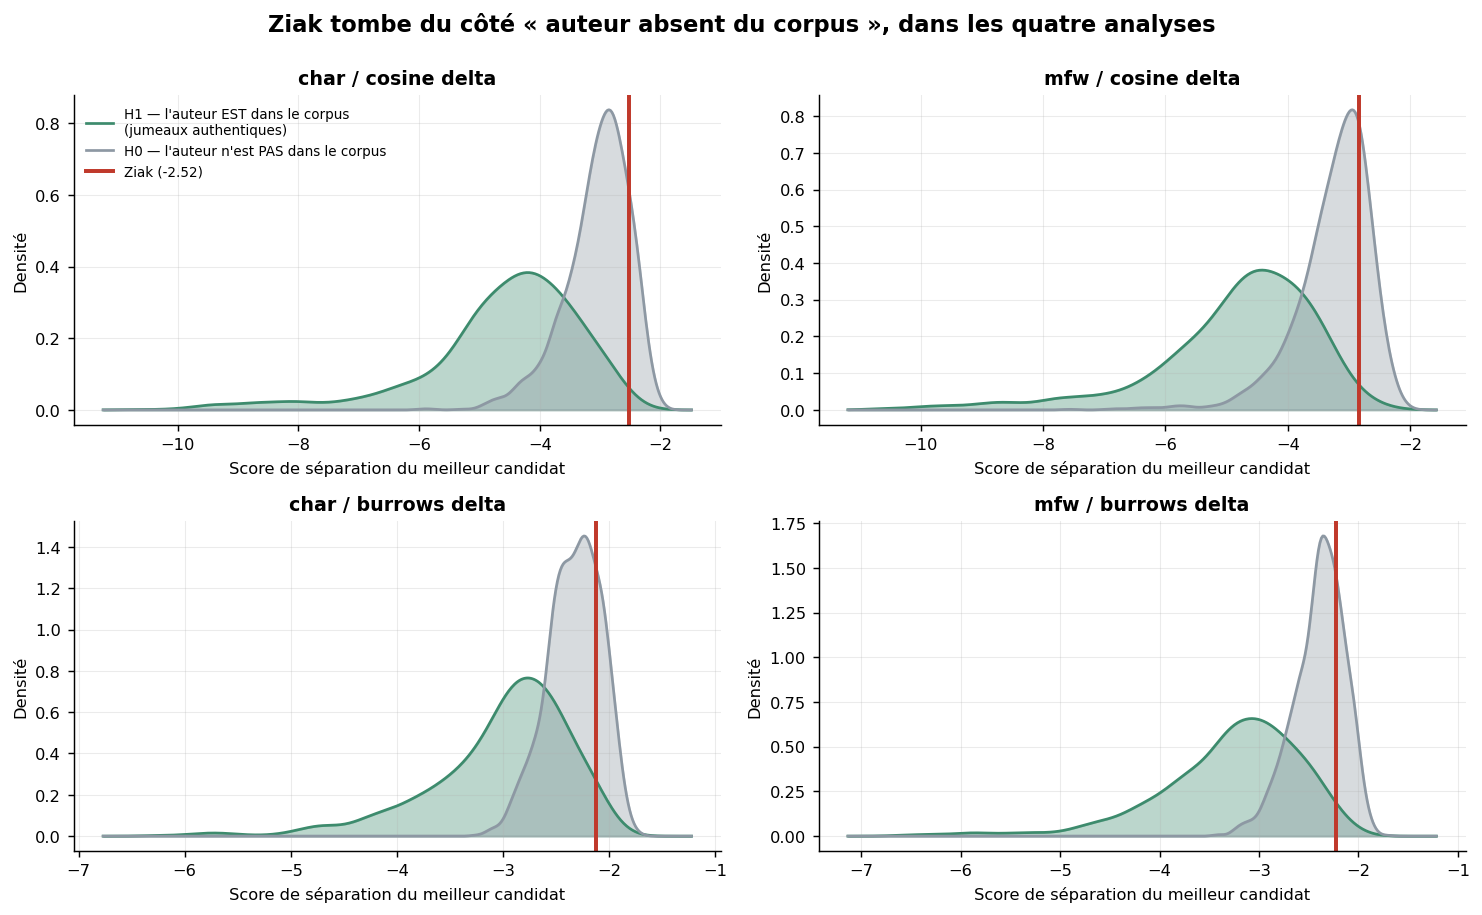

In [12]:
display(Image(filename=str(IMAGES_DIR / "04_1_verdict_H0_H1.png")))

**Les quatre analyses concordent : l'hypothèse « l'auteur n'est pas dans le corpus »
est favorisée à chaque fois.** Le score de séparation de Ziak (entre −2,1 et −2,8) est
non seulement très loin de ce que produit un alias authentique (−3,0 à −4,8), mais il
se situe même dans la queue *droite* de la distribution H0 : le meilleur candidat de
Ziak se détache encore moins du lot que dans le cas typique d'un auteur absent.

Autrement dit, ce n'est pas seulement que la méthode ne trouve pas ; c'est qu'elle
trouve activement l'absence de correspondance.

## 5. Robustesse : la conclusion tient-elle ?

Trois objections méritent une réponse chiffrée (script `05_robustesse.py`).

### 5.1 La méthode est-elle moins puissante sur les artistes récents ?

Ziak appartient à une génération au lexique homogène (drill et trap des années 2020).
Si la méthode y perdait sa puissance, le verdict serait fragile.

In [13]:
gen = pd.read_csv(RESULT_DIR / "05_1_puissance_par_generation.csv")
gen[gen["features"] == "char"].style.format(
    {"recall_at_1": "{:.1%}", "recall_at_5": "{:.1%}"}).hide(axis="index")

features,generation,recall_at_1,recall_at_5,n_essais,n_artistes
char,1990-2005,91.8%,100.0%,110,11
char,2006-2012,83.6%,96.8%,280,28
char,2013-2017,88.0%,98.6%,690,69
char,2018-2020,93.6%,98.6%,560,56
char,2021-2024,97.7%,100.0%,130,13


C'est l'inverse : la puissance est **maximale sur la génération de Ziak**
(97,7 % au premier rang pour 2021-2024). L'objection tombe.

### 5.2 Le seuil de 12 000 mots exclut-il le bon candidat ?

On fait varier la taille imposée aux documents, ce qui fait varier du même coup le
nombre d'artistes éligibles, de 268 à 472.

In [14]:
sens = pd.read_csv(RESULT_DIR / "05_2_sensibilite_seuil.csv")
sens.style.format({"sep_ziak_moy": "{:.2f}", "stabilite_top1": "{:.0%}",
                   "t_cand": "{:,.0f}"}).hide(axis="index")

t_cand,n_candidats,sep_ziak_moy,top1_modal,stabilite_top1
"5,000",472,-2.58,Dika,10%
"8,000",433,-2.52,Beendo Z,30%
"12,000",392,-2.43,Beendo Z,30%
"18,000",322,-2.43,Beendo Z,50%
"25,000",268,-2.46,Beendo Z,70%


Le score de séparation reste compris entre −2,43 et −2,58 sur toute la plage :
il ne franchit jamais le seuil qui indiquerait un auteur présent. La conclusion ne
dépend pas de ce réglage.

### 5.3 Les candidats récurrents résistent-ils à un test par paire ?

Le test des imposteurs (Koppel & Winter, 2014) ne demande plus « qui est le plus
proche ? » mais « ce candidat précis l'emporte-t-il sur un fond d'imposteurs tirés au
hasard ? ». On l'étalonne sur des jumeaux authentiques, sans quoi les scores ne
seraient pas interprétables.

In [15]:
imp = pd.read_csv(RESULT_DIR / "05_3_test_imposteurs.csv")
ref = pd.read_csv(RESULT_DIR / "05_4_imposteurs_reference.csv")

print(f"Étalon — vrais jumeaux (n = {len(ref)}) :")
print(f"  score médian   : {ref['score_imposteurs_jumeau'].median():.3f}")
print(f"  1er décile     : {ref['score_imposteurs_jumeau'].quantile(0.1):.3f}")
print(f"\nMeilleur candidat de Ziak : {imp.iloc[0]['candidat']} "
      f"({imp.iloc[0]['score_imposteurs']:.3f})")
print(f"Part des vrais jumeaux faisant moins bien : "
      f"{(ref['score_imposteurs_jumeau'] <= imp['score_imposteurs'].max()).mean():.1%}")
imp.style.format({"score_imposteurs": "{:.3f}",
                  "seuil_hasard": "{:.3f}"}).hide(axis="index")

Étalon — vrais jumeaux (n = 40) :
  score médian   : 1.000
  1er décile     : 0.974

Meilleur candidat de Ziak : Kerchak (0.825)
Part des vrais jumeaux faisant moins bien : 2.5%


candidat,score_imposteurs,seuil_hasard
Kerchak,0.825,0.038
Beendo Z,0.725,0.038
Rimkus,0.700,0.038
ISK,0.625,0.038
Werenoi,0.610,0.038
UZI (FRA),0.555,0.038
Lemon Haze,0.485,0.038
Zkr,0.060,0.038
SCH,0.025,0.038
L’Animalerie,0.000,0.038


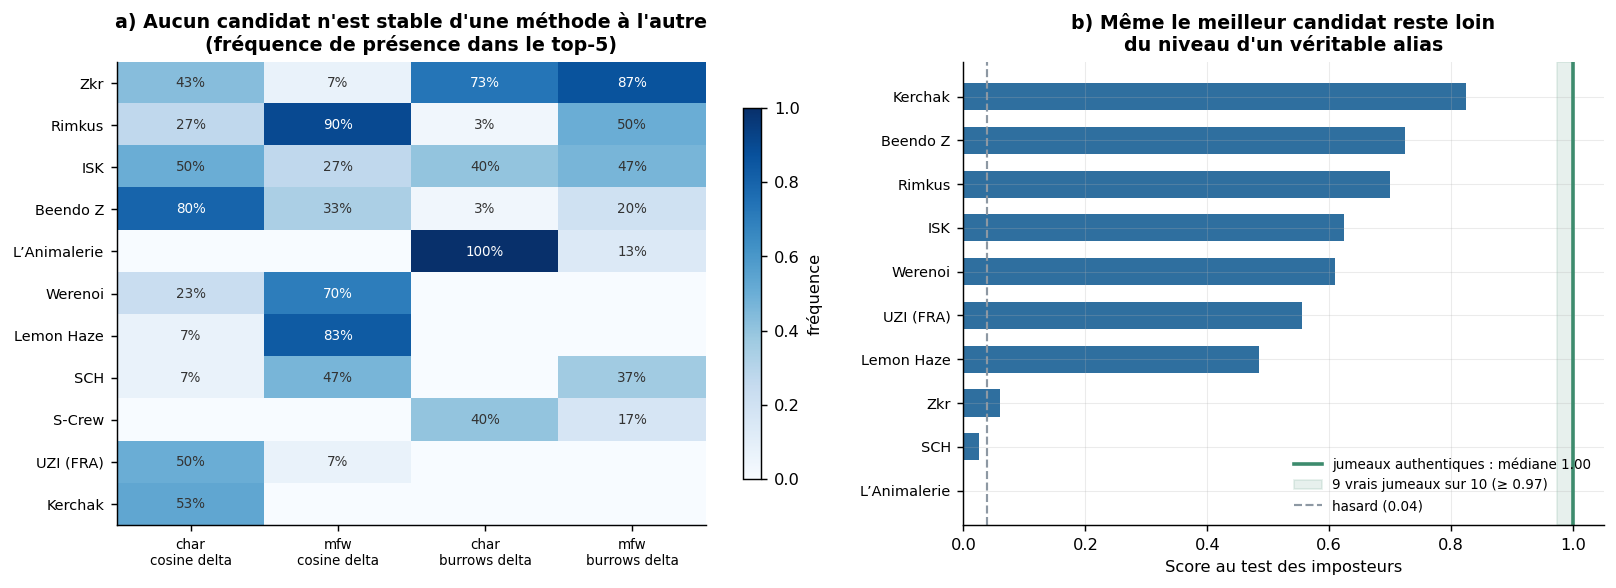

In [16]:
display(Image(filename=str(IMAGES_DIR / "05_1_candidats_imposteurs.png")))

Ce test appelle une lecture en deux temps, et c'est le résultat le plus nuancé de
l'étude.

D'un côté, les meilleurs candidats — Kerchak (0,83), Beendo Z (0,73), Rimkus (0,70) —
battent très largement le hasard (0,04). Il existe donc une **parenté stylistique
réelle** entre Ziak et ces artistes. Elle n'a rien de mystérieux : ce sont ses
contemporains directs, dans le même sous-genre.

De l'autre, un alias authentique obtient dans ce test un score **médian de 1,000**, et
neuf vrais jumeaux sur dix dépassent 0,974. Le meilleur candidat de Ziak reste sous le
niveau de 97,5 % des jumeaux authentiques. La parenté observée est celle d'une
communauté stylistique, pas celle d'une même main.

Cette distinction — ressembler à un courant *versus* être la même personne — est
précisément ce qu'un classement de distances non étalonné ne permet jamais de trancher.

## 6. Portrait stylométrique de Ziak

À défaut d'identifier Ziak, on peut le caractériser (script `06_profil_stylistique.py`).

### 6.1 Une position paradoxale

Deux mesures qu'il faut distinguer : la distance médiane de Ziak à *tout* le corpus,
qui dit s'il est atypique ; et la distance à son *plus proche* voisin, qui dit s'il a
un parent.

In [17]:
exc = pd.read_csv(RESULT_DIR / "06_1_excentricite.csv")
z = exc[exc["artiste"] == TARGET].iloc[0]
rang_min = int((exc["distance_min"] < z["distance_min"]).sum()) + 1

print(f"a) Distance médiane à l'ensemble du corpus")
print(f"   Ziak {z['distance_mediane_aux_autres']:.4f} — médiane du corpus "
      f"{exc['distance_mediane_aux_autres'].median():.4f}")
print(f"   Rang {int(z['rang_excentricite'])} / {len(exc)} : stylistiquement banal.\n")
print(f"b) Distance au voisin le plus proche")
print(f"   Ziak {z['distance_min']:.4f} (vers {z['voisin_le_plus_proche']}) — "
      f"médiane du corpus {exc['distance_min'].median():.4f}")
print(f"   Rang {rang_min} / {len(exc)} : {100 * rang_min / len(exc):.0f} % des "
      f"artistes ont un voisin plus proche que Ziak n'en a un.")

a) Distance médiane à l'ensemble du corpus
   Ziak 1.0062 — médiane du corpus 1.0056
   Rang 176 / 393 : stylistiquement banal.

b) Distance au voisin le plus proche
   Ziak 0.8505 (vers Beendo Z) — médiane du corpus 0.8196
   Rang 267 / 393 : 68 % des artistes ont un voisin plus proche que Ziak n'en a un.


Le résultat est doublement instructif. Ziak n'a rien d'un excentrique : il se situe au
milieu exact du genre (rang 176 sur 393), très loin des vrais atypiques du corpus que
sont Manau, Grand Corps Malade ou Rocé. Et pourtant **il n'a pas de proche parent** :
68 % des artistes ont un voisin plus proche que le sien.

C'est exactement la signature attendue d'un auteur qui écrit dans les codes d'un
courant sans qu'aucun artiste du corpus ne soit sa seconde identité.

### 6.2 Ce qui signe son écriture

In [18]:
marq = pd.read_csv(RESULT_DIR / "06_2_marqueurs_lexicaux.csv")
marq.nlargest(12, "z_log_odds")[
    ["mot", "z_log_odds", "n_occurrences_ziak", "freq_ziak_pour_mille",
     "freq_corpus_pour_mille", "ratio"]
].style.format({"z_log_odds": "{:.1f}", "freq_ziak_pour_mille": "{:.2f}",
                "freq_corpus_pour_mille": "{:.3f}", "ratio": "×{:.0f}"}
               ).hide(axis="index")

mot,z_log_odds,n_occurrences_ziak,freq_ziak_pour_mille,freq_corpus_pour_mille,ratio
uh,51.0,136,6.27,0.042,×149
huh,26.0,42,1.94,0.022,×87
pow,22.6,36,1.66,0.026,×64
copains,21.3,28,1.29,0.015,×89
know,20.6,40,1.84,0.053,×35
chrome,19.9,28,1.29,0.021,×63
zipette,15.3,18,0.83,0.016,×53
op,15.2,17,0.78,0.014,×58
libérez,14.5,18,0.83,0.020,×42
sheitan,13.6,24,1.11,0.054,×21


Les marqueurs les plus robustes sont des **onomatopées** : « uh » (149 fois plus
fréquent que dans le corpus), « huh » (×87), « pow » (×64) — les ad-libs qui ponctuent
ses morceaux et que les transcripteurs de Genius notent fidèlement. Viennent ensuite
un argot situé (« zipette », « sheitan », « op ») et des mots de son univers (« chrome »).

### 6.3 Un faux marqueur : l'élision

Une mise en garde s'impose sur ces marqueurs. Le trait le plus spectaculaire du
corpus de Ziak, à première vue, est un sous-emploi massif de « je » : cinq fois moins
que la moyenne. C'est un artefact.

In [19]:
el = pd.read_csv(RESULT_DIR / "06_5_controle_elision.csv")
el.style.format({c: "×{:.2f}" for c in ["ratio_forme_pleine", "ratio_forme_elidee",
                                        "ratio_cumule"]}).hide(axis="index")

forme_pleine,forme_elidee,ratio_forme_pleine,ratio_forme_elidee,ratio_cumule,artefact_de_transcription
je,j',×0.20,×1.22,×0.99,True
se,s',×0.22,×1.05,×0.78,False
ne,n',×0.35,×0.81,×0.61,False
me,m',×0.38,×0.96,×0.71,False
ce,c',×0.41,×1.07,×0.94,True
te,t',×0.59,×1.35,×1.15,True
que,qu',×0.61,×1.07,×0.85,True
de,d',×0.62,×1.40,×0.95,True
le,l',×0.92,×1.11,×1.01,False
la,l',×1.01,×1.11,×1.05,False


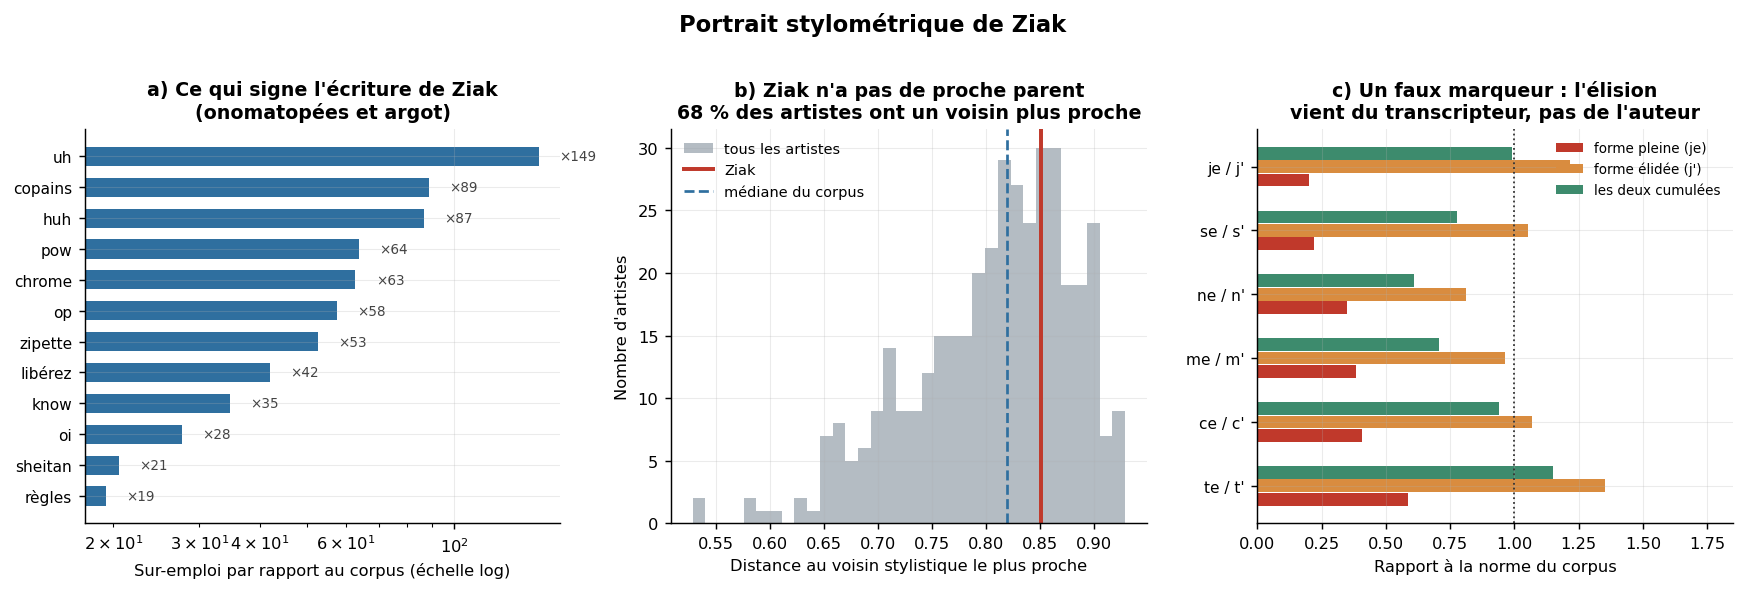

In [20]:
display(Image(filename=str(IMAGES_DIR / "06_1_profil_ziak.png")))

Ziak emploie « je » cinq fois moins que la moyenne — mais « j' » 1,2 fois plus, et
**une fois les deux formes additionnées, l'écart disparaît complètement (×0,99)**.
La moitié des paires testées relève du même artefact.

Ce que l'on mesurait n'était pas une habitude d'écriture mais une convention de
transcription : les paroles de Genius sont saisies par des contributeurs bénévoles, et
« j'suis » ou « je suis » notent la même diction. C'est une limite structurelle des
corpus de paroles, et une raison de plus de valider un protocole avant de l'interpréter.

### 6.4 Stabilité temporelle

Une signature d'auteur suppose une certaine constance. On compare les deux périodes
de production de Ziak, en prenant pour repère l'écart entre deux moitiés aléatoires
de son œuvre.

In [21]:
st = pd.read_csv(RESULT_DIR / "06_3_stabilite_temporelle.csv").iloc[0]
print(f"Période 2020-2021 : {int(st['n_titres_periode_1'])} titres")
print(f"Période 2022-2024 : {int(st['n_titres_periode_2'])} titres")
print(f"\nDistance entre les deux périodes  : "
      f"{st['distance_2020_2021_vs_2022_2024']:.4f}")
print(f"Distance entre moitiés aléatoires : "
      f"{st['distance_moities_aleatoires_ziak_moy']:.4f} "
      f"(± {st['distance_moities_aleatoires_ziak_sd']:.4f})")
print(f"Écart standardisé : z = {st['z_vs_moitiés_aleatoires']:+.2f}")

Période 2020-2021 : 23 titres
Période 2022-2024 : 20 titres

Distance entre les deux périodes  : 0.7589
Distance entre moitiés aléatoires : 0.7279 (± 0.0180)
Écart standardisé : z = +1.71


L'écart entre 2020-2021 et 2022-2024 dépasse à peine ce que produit une coupe
aléatoire (z = +1,7, sous le seuil usuel de 2). Le style évolue un peu, sans rupture :
rien n'indique un changement de plume au cours de la période.

## 7. Limites

Quatre réserves délimitent la portée du résultat.

**Le corpus n'est pas le rap français.** LRFAF couvre 596 artistes, et l'analyse
n'en retient que 393 (Ziak compris) — ceux qui disposent d'au moins 12 000 mots. Un artiste peu
documenté, ou absent de Genius, ne pouvait pas être détecté. La conclusion porte sur
le pool testé, pas sur l'ensemble des rappeurs francophones.

**Les featurings ne sont pas séparés.** Les paroles du corpus ne comportent aucune
balise de section : lorsqu'un invité intervient sur un titre, son couplet est attribué
à l'artiste principal. Ce bruit affecte Ziak comme les candidats, et il tend à
rapprocher artificiellement les artistes qui collaborent — donc à faciliter une
détection, pas à l'empêcher.

**Les transcriptions sont médiées.** Comme le montre la section 6.3, une partie du
signal apparent vient des contributeurs de Genius plutôt que des artistes. Les
4-grammes de caractères y sont moins sensibles que les mots, mais pas immunisés.

**Un alias n'écrit pas forcément comme lui-même.** Un artiste changeant délibérément
d'identité peut changer de registre. La validation de la section 3 mesure la puissance
sur des jumeaux « faciles » — deux moitiés d'une même œuvre — et fournit donc une
borne *optimiste*. Autrement dit, 90 % est le taux de détection dans le cas favorable ;
face à un alias qui se dissimulerait activement, il serait plus bas.

Cette dernière limite est la plus sérieuse, et elle joue dans un seul sens : elle
affaiblit la conclusion « Ziak n'est personne du corpus » sans jamais soutenir une
identification particulière. Aucun des candidats testés n'atteint le niveau d'un alias.

## 8. Conclusion

L'hypothèse du pseudonyme était testable, et le test est concluant : **aucun des 392 autres
artistes éligibles du corpus LRFAF ne présente la signature stylométrique de Ziak**,
alors qu'un protocole validé sur 177 cas connus retrouve le bon auteur neuf fois sur
dix — et dans 97,7 % des cas pour sa génération. Les quatre analyses menées
convergent vers l'hypothèse d'un auteur absent du corpus, et le test par paire montre
que même le meilleur candidat reste en deçà de 97,5 % des alias authentiques.

Ce que l'on observe à la place a sa propre valeur descriptive : Ziak écrit au centre
de son genre, sans excentricité mesurable, mais sans proche parent non plus. Sa
parenté avec Kerchak ou Beendo Z est celle d'une génération et d'un sous-genre
partagés, pas d'une main commune.

La contribution la plus transposable de ce travail est cependant méthodologique.
Une même question, posée à un même corpus, reçoit deux réponses opposées selon le
protocole : l'approche intuitive désigne ISK avec assurance et se trompe trois fois
sur quatre ; l'approche étalonnée ne désigne personne, et sait dire pourquoi. Entre
les deux, il n'y a pas un algorithme plus sophistiqué, mais trois exigences ordinaires
— contrôler une variable de confusion, valider sur des cas connus, calibrer contre une
hypothèse nulle.

### Note éthique

Cette étude porte sur une personne réelle qui a fait le choix de l'anonymat. Deux
précautions ont guidé le travail. D'abord, elle s'appuie exclusivement sur des données
publiques de recherche et sur des textes publiés, sans recours à aucune information
personnelle. Ensuite, et surtout, la stylométrie n'établit pas d'identité civile :
une correspondance forte aurait constitué un indice de parenté textuelle, jamais une
preuve — et elle aurait appelé, à ce titre, une retenue plus grande encore dans sa
publication que le résultat négatif obtenu ici.

Le résultat de cette enquête est d'ailleurs, à sa manière, une confirmation de la
robustesse de cet anonymat face aux méthodes quantitatives.

### Références

- Burrows, J. (2002). *Delta: a measure of stylistic difference and a guide to likely
  authorship*. Literary and Linguistic Computing, 17(3), 267-287.
- Evert, S., Proisl, T., Jannidis, F. *et al.* (2017). *Understanding and explaining
  Delta measures for authorship attribution*. Digital Scholarship in the Humanities, 32.
- Koppel, M. & Winter, Y. (2014). *Determining if two documents are written by the
  same author*. JASIST, 65(1), 178-187.
- Monroe, B., Colaresi, M. & Quinn, K. (2008). *Fightin' words: lexical feature
  selection and evaluation for identifying the content of political conflict*.
  Political Analysis, 16(4), 372-403.
- Smith, P. & Aldridge, W. (2011). *Improving authorship attribution: optimizing
  Burrows' Delta method*. Journal of Quantitative Linguistics, 18(1), 63-88.
- de Courson, B. (2024). *LRFAF : une exploration numérique du rap français depuis
  les années 1990*.